In [1]:
# Parameters
BATCH_MODE = "true"
print(f"BATCH_MODE={BATCH_MODE}")


BATCH_MODE=true


**Navigation** : [Index](../../README.md) | [<< Précédent](03-3-Performance-Optimization.ipynb)

# Pipeline VLM in-graph : character design depuis une image de référence

**Module :** 03-Orchestration (multi-modèles)
**Niveau :** Avancé
**Durée estimée :** 50 minutes
**Services :** ComfyUI auto-hébergé (GPU RTX 3090)

## Introduction

Ce notebook naît d'une image. Une *character sheet* de style blueprint -- un personnage
dessiné en multiples vues avec cotes et annotations techniques -- a circulé sur un forum ;
ce qui la rend remarquable n'est pas seulement son rendu, mais ceci : **le fichier PNG
embarque le workflow ComfyUI complet qui l'a produite**, et ce workflow contient une boucle
de raisonnement. Il ne se contente pas de générer une image depuis un prompt écrit à la
main : un modèle de vision-langage (VLM) **à l'intérieur du graphe** examine une image de
référence quelconque (animal, plante, objet, paysage...) et rédige lui-même le prompt de
character design avant que le modèle de diffusion ne s'exécute.

Nous allons faire trois choses, dans l'ordre :

1. **Forensics PNG** -- extraire le workflow des métadonnées de l'image par simple parsing
   binaire, sans aucun outil magique : un PNG est une suite de chunks, et ComfyUI y écrit
   deux clés de texte.
2. **Lecture du graphe** -- reconstituer le pipeline node par node, comprendre ses choix
   (double encodeur, CFG 1.0, résolution, LoRA de style), et identifier les trois idées
   qui le rendent ingénieux.
3. **Rejouer le pipeline** sur notre stack locale : même architecture, même prompt système
   VLM, mêmes poids de diffusion (Krea 2 turbo), en substituant aux custom nodes de
   l'auteur leurs équivalents natifs.

### Les trois idées à retenir

| # | Idée | Où la voir |
|---|------|-----------|
| 1 | **Le PNG auto-documenté** : chaque image ComfyUI embarque son propre graphe, reproductible par quiconque la possède | Section 1 |
| 2 | **La boucle VLM in-graph** : le prompt n'est pas écrit, il est *généré par un VLM qui regarde une image de référence* -- ComfyUI devient un pipeline agentic | Section 5 |
| 3 | **Le prompt système « visual DNA »** : 11 235 caractères qui contraignent le VLM à produire un *design blueprint* style-agnostique -- le style visuel est délégué au LoRA, pas au prompt | Section 3 |

> **Note savante -- deux formats d'un même workflow.** ComfyUI écrit deux représentations
> distinctes dans les métadonnées : `prompt` (le format API : un dictionnaire de nodes
> avec leurs entrées, directement soumissible à `POST /prompt`) et `workflow` (le format
> UI : positions, widgets, liens -- ce que l'éditeur graphique recharge). Le premier est
> un *programme* ; le second est une *capture d'écran structurée*. C'est le premier que
> nous allons exécuter.

## Architecture du pipeline extrait

```mermaid
flowchart TD
    REF(["Image de référence<br/>(animal, plante, objet...)"]) --> SCALE["ImageScaleToTotalPixels<br/>1.0 megapixel"]
    SCALE --> VLM["TextGenerate (VLM in-graph)<br/>gemma4_12b + system prompt<br/>'visual DNA'"]
    VLM -->|"prompt character design<br/>style-agnostique"| JOIN["JoinStrings<br/>trigger words + prompt"]
    TW["TriggerWord Toggle<br/>'banjiesock2style, illustration'"] --> JOIN
    LORA["LoraLoader<br/>banjiesock_Krea2 : 1.0"] -->|"MODEL patché"| PATCH["PathchSageAttentionKJ<br/>(SageAttention, désactivé ici)"]
    UNET["UNETLoader<br/>krea2_turbo_int8_convrot"] --> LORA
    CLIPA["CLIPLoader<br/>qwen3vl_4b_bf16"] --> LORA
    JOIN --> ENC["CLIPTextEncode<br/>(via CLIP patché par le LoRA)"]
    LORA --> ENC
    ENC -->|"positive"| KS["KSampler<br/>er_sde, simple, 8 steps<br/>CFG 1.0, seed fixe"]
    ENC -->|"negative"| ZO["ConditioningZeroOut<br/>(négatif vide)"] --> KS
    RM["ResolutionMaster<br/>1280 x 1856"] -->|"latent"| KS
    KS --> DEC["VAEDecode<br/>qwen_image_vae"]
    DEC --> SAVE(["SaveImage<br/>character sheet finale"])
    VLM -.->|"Display Any<br/>(inspection UI)"| HIST(["humain"])
```

> **Lecture.** Le graphe se lit en deux temps. D'abord le **couloir VLM** (haut) : la
> référence est mise à l'échelle, examinée par le VLM, qui rend un prompt de character
> design -- affiché dans l'UI par un node `Display Any`. Puis le **couloir diffusion**
> (bas) : le prompt reçoit un préfixe de trigger words (le style *banjiesock*, porté par
> un LoRA), il est encodé par le text encoder patché, et le sampler distillé produit
> l'image en 8 steps à CFG 1.0. Les deux couloirs ne partagent que le texte généré.

In [2]:
# Verification des dependances externes
import importlib

_DEPS_STATUS = {}
for mod in ('PIL', 'requests', 'matplotlib', 'numpy', 'dotenv'):
    try:
        importlib.import_module(mod)
        _DEPS_STATUS[mod] = True
    except ImportError:
        _DEPS_STATUS[mod] = False
        print(f'WARNING: {mod} non installe - pip install {mod}')

_all_deps_ok = all(_DEPS_STATUS.values())
print('Toutes les dependances sont disponibles' if _all_deps_ok
      else f'Dependances manquantes: {[k for k, v in _DEPS_STATUS.items() if not v]}')

# Imports de la session
import io
import json
import os
import struct
import time
import uuid
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

# Dossier d'assets du notebook (workflow embarque, image source, prompt systeme)
ASSETS = Path('assets/krea2-character')
SOURCE_PNG = ASSETS / 'source_character_sheet.png'

print('Assets disponibles :', sorted(p.name for p in ASSETS.iterdir()))

Toutes les dependances sont disponibles


Assets disponibles : ['reference_robot.png', 'source_character_sheet.png', 'vlm_system_prompt.txt', 'workflow_api.json', 'workflow_ui.json']


## 1. Forensics PNG : le workflow est dans l'image

Un fichier PNG n'est pas un bloc opaque : c'est une **séquence de chunks** binaires, chacun
préfixé par sa longueur (4 octets big-endian) et son type (4 octets ASCII). Le décodage
commence après la signature `\x89PNG\r\n\x1a\n` (8 octets) et chaque chunk se termine
par un CRC (4 octets) :

```
[longueur: 4o][type: 4o][données: longueur octets][crc: 4o]
```

Le chunk qui nous intéresse est **`tEXt`** : une paire clé/valeur encodée
`mot-clé\x00texte`. ComfyUI y écrit deux clés à chaque sauvegarde :

| Clé tEXt | Contenu | Usage |
|----------|---------|-------|
| `prompt` | Le graphe au **format API** (dict de nodes) | directement soumissible à `POST /prompt` |
| `workflow` | Le graphe au **format UI** (positions, liens, widgets) | rechargé par l'éditeur graphique |

Deux conséquences pratiques :

- **Reproductibilité par défaut** : quiconque reçoit une image ComfyUI peut en rejouer le
  pipeline -- pas de « comment as-tu obtenu ce rendu ? », la recette voyage avec le plat.
- **Traçabilité** : seeds, checkpoints, LoRA, paramètres de sampling sont gravés. C'est
  aussi une surface d'information : avant de publier une image générée, on peut vouloir
  savoir ce qu'elle raconte sur sa propre fabrication.

> **Note savante -- encodage.** La spécification PNG officielle limite `tEXt` à Latin-1 ;
> ComfyUI y écrit de l'UTF-8 par convention de facto. Notre parseur décode donc en UTF-8
> avec `errors="replace"` : c'est la convention du terrain, pas celle du spec.

In [3]:
# =============================================================================
# 1. PARSER BINAIRE DES CHUNKS tEXt D'UN PNG
# =============================================================================

PNG_SIGNATURE = b'\x89PNG\r\n\x1a\n'

def parse_png_text_chunks(png_bytes: bytes) -> dict:
    """Extrait les chunks tEXt d'un PNG par simple lecture de sa structure binaire.

    Un PNG = signature (8 octets) puis une suite de chunks :
    [longueur 4o big-endian][type 4o ascii][donnees][crc 4o].
    Seuls les chunks tEXt (cle\x00texte) sont retournes.
    """
    if png_bytes[:8] != PNG_SIGNATURE:
        raise ValueError('Le fichier ne commence pas par la signature PNG')
    texts = {}
    offset = 8
    n = len(png_bytes)
    while offset + 8 <= n:
        (length,) = struct.unpack('>I', png_bytes[offset:offset + 4])
        ctype = png_bytes[offset + 4:offset + 8].decode('ascii', errors='replace')
        payload = png_bytes[offset + 8:offset + 8 + length]
        if ctype == 'tEXt':
            keyword, _, text = payload.partition(b'\x00')
            # ComfyUI ecrit de l'UTF-8 dans tEXt (convention de facto, cf. prose)
            texts[keyword.decode('utf-8', errors='replace')] = text.decode('utf-8', errors='replace')
        offset += 12 + length  # 4 (len) + 4 (type) + length (donnees) + 4 (crc)
        if ctype == 'IEND':
            break
    return texts

# --- Application a l'image source (la character sheet qui a motive ce notebook) ---
source_bytes = SOURCE_PNG.read_bytes()
text_chunks = parse_png_text_chunks(source_bytes)

print(f'Taille du PNG : {len(source_bytes):,} octets'.replace(',', ' '))
print(f'Chunks tEXt trouves : {list(text_chunks)}')
for key, val in text_chunks.items():
    print(f'  - {key!r}: {len(val):,} caracteres'.replace(',', ' '))

# Le chunk "prompt" est du JSON au format API : chargeons-le
embedded_api_graph = json.loads(text_chunks['prompt'])
print(f'\nGraphe API embarque : {len(embedded_api_graph)} nodes executes')

Taille du PNG : 2 201 103 octets
Chunks tEXt trouves : ['prompt', 'workflow']
  - 'prompt': 15 627 caracteres
  - 'workflow': 42 300 caracteres

Graphe API embarque : 19 nodes executes


## 2. Lecture du graphe : qui fait quoi

Le format API est un dictionnaire `{id_du_node: {class_type, inputs}}` où les entrées sont
soit des **valeurs** (seed, texte, nom de fichier) soit des **liens** `["id_source", slot]`.
En listant les `class_type` et en suivant les liens, on reconstitue le pipeline sans
jamais ouvrir l'interface graphique.

### Le pipeline reconstitué

| Étape | Nodes | Rôle |
|-------|-------|------|
| Acquisition | `LoadImage` (référence) → `ImageScaleToTotalPixels` (1.0 MP, lanczos) | l'image entre dans le graphe, normalisée pour le VLM |
| Génération du prompt | `CLIPLoader` (gemma4_12b, type krea2) → `TextGenerate` (11 235 caractères de system prompt) | le VLM **regarde** la référence et **écrit** le prompt de character design |
| Assemblage | `TriggerWord Toggle` + `JoinStrings` | préfixe les trigger words du LoRA (`banjiesock2style, illustration`) au prompt généré |
| Encodage | `UNETLoader` (krea2_turbo_int8) + `CLIPLoader` (qwen3vl_4b) → `Lora Loader` → `PathchSageAttentionKJ` → `CLIPTextEncode` | le LoRA patche modèle ET encodeur ; SageAttention patch (désactivé dans cette exécution) |
| Sampling | `ResolutionMaster` (1280×1856) + `KSampler` (er_sde, simple, 8 steps, **CFG 1.0**) + `ConditioningZeroOut` | modèle **distillé** : pas de vrai négatif, d'où le ZeroOut |
| Sortie | `VAEDecode` (qwen_image_vae) → `SaveImage` / `PreviewImage` + `Display Any` (inspection du texte généré) | l'image finale + la traçabilité |

Trois choix méritent une explication :

- **Deux CLILoader, deux rôles.** `gemma4_12b` sert de **VLM de génération** (il produit
  du texte), `qwen3vl_4b` sert d'**encodeur de diffusion** (il consomme du texte). Le
  workflow charge deux LLM pour deux fonctions différentes -- c'est la marque d'un
  pipeline pensé, pas assemblé.
- **CFG 1.0 + ConditioningZeroOut.** Un modèle distillé (turbo) n'utilise pas le
  conditionnement négatif : plutôt qu'encoder un prompt négatif factice, le workflow
  **met le positive à zéro** -- un négatif vide mathématiquement propre.
- **Le LoRA patche aussi le CLIP.** `Lora Loader (LoraManager)` reçoit model ET clip :
  les trigger words (`banjiesock2style`) ne seraient pas interprétés sans le patch côté
  encodeur.

In [4]:
# =============================================================================
# 2. ANALYSE PROGRAMMATIQUE DU GRAPHE EMBARQUE
# =============================================================================

# Le workflow embarque une copie des metadonnees : utilisons celle du repo (identique)
# pour garder le notebook lisible, mais verifions d'abord la correspondance.
repo_api = json.loads((ASSETS / 'workflow_api.json').read_text(encoding='utf-8'))
assert repo_api == embedded_api_graph, 'le JSON du repo diverge du PNG source'
print('workflow_api.json == chunk tEXt "prompt" du PNG (verifie)')

# --- Inventaire des nodes par type ---
from collections import Counter
types = Counter(n['class_type'] for n in repo_api.values())
print(f'\n{len(repo_api)} nodes, {len(types)} types distincts :')
for t, cnt in types.most_common():
    print(f'  {cnt}x {t}')

# --- Extraction des parametres pivots ---
def node_of(cls):
    return next(v for v in repo_api.values() if v['class_type'] == cls)

ks = node_of('KSampler')['inputs']
rm = node_of('ResolutionMaster')['inputs']
print('\nParametres de sampling :')
print(f"  sampler={ks['sampler_name']!r} scheduler={ks['scheduler']!r} "
      f"steps={ks['steps']} cfg={ks['cfg']} denoise={ks['denoise']}")
print(f"  seed={ks['seed']:,}".replace(',', ' '), f"(reproductible : grave dans le PNG)")
print(f"  resolution={rm['width']}x{rm['height']} (mode {rm['mode']}, rescale {rm['rescale_value']})")

print('\nModeles charges :')
print(f"  UNET : {node_of('UNETLoader')['inputs']['unet_name']}")
for nid, n in repo_api.items():
    if n['class_type'] == 'CLIPLoader':
        print(f"  CLIP : {n['inputs']['clip_name']} (node {nid})")
print(f"  VAE  : {node_of('VAELoader')['inputs']['vae_name']}")
lora_text = node_of('Lora Loader (LoraManager)')['inputs']['text']
print(f"  LoRA : {lora_text}")
tg = node_of('TextGenerate')['inputs']
print(f"\nTextGenerate : system prompt de {len(tg['prompt']):,} caracteres".replace(',', ' '))
print(f"  sampling : temperature={tg['sampling_mode.temperature']} "
      f"top_k={tg['sampling_mode.top_k']} top_p={tg['sampling_mode.top_p']} "
      f"min_p={tg['sampling_mode.min_p']} rep_penalty={tg['sampling_mode.repetition_penalty']}")

workflow_api.json == chunk tEXt "prompt" du PNG (verifie)

19 nodes, 18 types distincts :
  2x CLIPLoader
  1x VAEDecode
  1x CLIPTextEncode
  1x VAELoader
  1x KSampler
  1x UNETLoader
  1x ResolutionMaster
  1x SaveImage
  1x PreviewImage
  1x Display Any (rgthree)
  1x PathchSageAttentionKJ
  1x Lora Loader (LoraManager)
  1x TriggerWord Toggle (LoraManager)
  1x JoinStrings
  1x ConditioningZeroOut
  1x ImageScaleToTotalPixels
  1x TextGenerate
  1x LoadImage

Parametres de sampling :
  sampler='er_sde' scheduler='simple' steps=8 cfg=1.0 denoise=1.0
  seed=145 581 514 722 929 (reproductible : grave dans le PNG)
  resolution=1280x1856 (mode Manual, rescale 1.5)

Modeles charges :
  UNET : krea2_turbo_int8_convrot.safetensors
  CLIP : qwen3vl_4b_bf16.safetensors (node 45)
  CLIP : gemma4_12b_int8_convrot.safetensors (node 91)
  VAE  : qwen_image_vae.safetensors
  LoRA : <lora:banjiesock_Krea2:1.00>

TextGenerate : system prompt de 11 235 caracteres
  sampling : temperature=0.7 top_k=

## 3. Le cœur ingénieux : le prompt système « visual DNA »

L'idée la plus riche du workflow n'est pas un node, c'est un **texte** : les 11 235
caractères qui définissent la mission du VLM. Le concept est résumé par l'auteur en une
formule : *« visual DNA → human character design »* -- traduire l'identité visuelle d'une
référence quelconque en langage de design d'un personnage **humain original**.

Cinq contraintes structurelles font tout le travail :

1. **Le personnage doit être humain.** Ni mascotte, ni version anthropomorphique du
   sujet : l'auteur interdit explicitement les oreilles/queues/ailes littérales.
2. **Le genre est un choix de design, pas un défaut.** Le VLM doit décider masculin ou
   féminin *à partir des qualités visuelles de la référence* (silhouette, énergie,
   couleurs), jamais par stéréotype ni par automatisme.
3. **Neutralité art-style stricte.** Le prompt généré ne doit prescrire *aucun* médium,
   style, niveau de réalisme ni éclairage : le même personnage doit pouvoir être rendu en
   croquis, en line art, en anime ou en semi-réaliste. Les mots interdits sont listés
   (`photorealistic`, `cinematic`, `highly detailed`...).
4. **Traduction métaphorique, pas costume.** Les feuilles d'un oiseau deviennent des
   couches de tissu, ses marques deviennent des motifs textiles, sa posture devient un
   langage corporel. La règle : *translate characteristics rather than copying the
   subject literally*.
5. **Un blueprint, pas un rendu.** La sortie se termine par l'exigence d'une description
   de type *design blueprint* : assez concrète pour préserver l'identité du personnage à
   travers tous les styles, assez ouverte pour laisser le choix du rendu.

La conséquence architecturale est élégante : **le style visuel est délégué au LoRA** (les
trigger words `banjiesock2style, illustration` préfixés au prompt), tandis que **le VLM ne
porte que l'identité du personnage**. Design et style voyagent dans deux canaux séparés,
composables à volonté -- c'est exactement la séparation de préoccupations qu'on attend
d'un bon pipeline.

In [5]:
# =============================================================================
# 3. LE PROMPT SYSTEME ORIGINAL, PAR EXTRAITS SIGNIFICATIFS
# =============================================================================

system_prompt = (ASSETS / 'vlm_system_prompt.txt').read_text(encoding='utf-8')
print(f'Longueur totale : {len(system_prompt):,} caracteres'.replace(',', ' '))
print(f'Lignes : {len(system_prompt.splitlines())}')

# Extraits cles, choisis pour la lecture pedagogique (le texte integral est dans assets/)
EXTRAITS = [
    ('La mission', 'You are a visual-to-character-design prompt writer.'),
    ('La contrainte humaine', 'The resulting character MUST be human. Do not create an anthropomorphic animal, '
     'humanoid creature, monster, mascot, or non-human character.'),
    ('Le genre comme choix de design', 'The character may be either male or female. You must decide which is more '
     'appropriate based on the visual qualities, shapes, associations, proportions, energy, '
     'and overall character suggested by the reference.'),
    ('La neutralite de style', 'Do not include style-dependent phrases such as "highly detailed," "photorealistic," '
     '"cinematic," "realistic skin," "intricate rendering," "dramatic lighting," "digital painting,"'),
    ('La traduction metaphorique', "a bird's feather arrangement might become layered fabric, sleeves, hair "
     'ornaments, jewelry, or repeating decorative shapes'),
    ('La separation design / rendu', "Think of the output as a description of the character's DESIGN BLUEPRINT, "
     'not a description of how the finished artwork should be rendered.'),
    ('La formule resume', 'Think of the process as "visual DNA \u2192 human character design."'),
]
for titre, extrait in EXTRAITS:
    pos = system_prompt.find(extrait[:40])
    print(f'\n--- {titre} (offset {pos}) ---')
    print(f'"{extrait}"')

Longueur totale : 11 235 caracteres
Lignes : 159

--- La mission (offset 0) ---
"You are a visual-to-character-design prompt writer."

--- La contrainte humaine (offset 458) ---
"The resulting character MUST be human. Do not create an anthropomorphic animal, humanoid creature, monster, mascot, or non-human character."

--- Le genre comme choix de design (offset 599) ---
"The character may be either male or female. You must decide which is more appropriate based on the visual qualities, shapes, associations, proportions, energy, and overall character suggested by the reference."

--- La neutralite de style (offset 2157) ---
"Do not include style-dependent phrases such as "highly detailed," "photorealistic," "cinematic," "realistic skin," "intricate rendering," "dramatic lighting," "digital painting,""

--- La traduction metaphorique (offset 8725) ---
"a bird's feather arrangement might become layered fabric, sleeves, hair ornaments, jewelry, or repeating decorative shapes"

--- La separ

## 4. Client ComfyUI : authentification et santé de la stack

Le service ComfyUI de la stack locale est derrière **ComfyUI-Login** : les appels portent
un jeton `Bearer` lu depuis le fichier `.env` de la série (`MyIA.AI.Notebooks/GenAI/.env`,
gitignore). Le jeton ne figure jamais dans le notebook -- c'est la discipline
`secrets-hygiene` du dépôt : les identifiants vivent dans des fichiers ignorés, jamais
inline.

Le chargement des poids est le coût dominant de la session : le UNet int8 fait 13,5 Go,
le VLM/encodeur 8,9 Go. ComfyUI gère l'éviction : le VLM travaille d'abord (phase
prompt), puis laisse la place au UNet (phase sampling). Sur une RTX 3090 (24 Go), les
deux phases tiennent -- séparément.

In [6]:
# =============================================================================
# 4. CLIENT HTTP COMFYUI (meme pattern que les notebooks 01-5 / 02-1)
# =============================================================================
from dotenv import load_dotenv

load_dotenv('../.env')  # MyIA.AI.Notebooks/GenAI/.env (gitignore : jamais committe)

COMFYUI_URL = os.environ['COMFYUI_API_URL'].rstrip('/')
COMFYUI_TOKEN = os.environ['COMFYUI_AUTH_TOKEN']

session = requests.Session()
session.headers.update({'Authorization': f'Bearer {COMFYUI_TOKEN}'})

stats = session.get(f'{COMFYUI_URL}/system_stats', timeout=30).json()
dev = stats['devices'][0]
print(f"ComfyUI : {stats['system']['comfyui_version']}")
print(f"GPU     : {dev['name']} | VRAM libre {dev['vram_free']/1e9:.1f} / {dev['vram_total']/1e9:.1f} Go")

# --- Poids requis par le pipeline (tous telecharges depuis Comfy-Org/Krea-2) ---
oi = session.get(f'{COMFYUI_URL}/object_info', timeout=300).json()
def folder_models(node, key):
    return set(oi[node]['input']['required'][key][0])

REQUIRED = {
    'UNETLoader': ('unet_name', 'krea2_turbo_int8_convrot.safetensors'),
    'CLIPLoader': ('clip_name', 'qwen3vl_4b_bf16.safetensors'),
    'VAELoader': ('vae_name', 'qwen_image_vae.safetensors'),
    'LoraLoader': ('lora_name', 'banjiesock_Krea2.safetensors'),
}
for node, (key, fname) in REQUIRED.items():
    present = fname in folder_models(node, key)
    print(f"  {'OK ' if present else 'ABSENT'} {fname}")
    assert present, (
        f'{fname} est requis - sources : Comfy-Org/Krea-2 (HF) pour les trois premiers, '
        f'Civitai modele 2937073 pour le LoRA (cf. assets/krea2-character/ et le README de la serie)')

# Nodes natifs qui remplacent les custom nodes de l'auteur (cf. tableau section 6)
for cls in ('TextGenerate', 'PreviewAny', 'StringConcatenate', 'EmptySD3LatentImage'):
    assert cls in oi, f'node natif {cls} absent de ce ComfyUI'
print('Nodes natifs requis : tous presents')

ComfyUI : 0.36.0
GPU     : cuda:0 NVIDIA GeForce RTX 3090 : cudaMallocAsync | VRAM libre 18.8 / 25.8 Go


  OK  krea2_turbo_int8_convrot.safetensors
  OK  qwen3vl_4b_bf16.safetensors
  OK  qwen_image_vae.safetensors
  OK  banjiesock_Krea2.safetensors
Nodes natifs requis : tous presents


## 5. Étape 1 du pipeline : le VLM écrit le prompt

Nous reproduisons le couloir VLM du workflow original, avec une adaptation documentée :

| Original (custom) | Notre exécution (natif) | Différence |
|---|---|---|
| `TextGenerate` avec `gemma4_12b_int8_convrot` | `TextGenerate` avec `qwen3vl_4b_bf16` | même node natif, VLM plus léger (4B vs 12B) qui sert **aussi** d'encodeur à l'étape suivante -- un seul chargement de poids pour deux rôles |
| `Display Any (rgthree)` | `PreviewAny` | équivalent natif ; rend le texte dans `history` |
| `ImageScaleToTotalPixels` | identique (natif) | néant |

Le system prompt est celui de l'auteur, **intègre** (11 235 caractères) : c'est lui qu'on
étudie. Notre référence de démonstration est le **robot photoréaliste du notebook `03-1`**
(panneau droit de la comparaison multi-modèles) : un objet/créature artificielle aux
yeux cyan -- exactement le terrain où la traduction métaphorique du system prompt
s'exprime le mieux.

> **Note savante -- alignement du petit VLM.** Le contrat du system prompt couvre
> *explicitement* les paysages (« landscape, natural phenomenon »), mais le Qwen3-VL 4B
> **refuse** ce cas : « a natural landscape does not contain any inherent human
> features » (refus constaté firsthand sur une référence chalet). Le gemma4_12b de
> l'auteur suivait l'instruction complète. C'est une limite d'instruction-following
> des petits modèles, pas une limite du pipeline -- et une piqûre de rappel utile :
> dans une boucle agentic, le maillon linguistique a ses propres refus.

In [7]:
# =============================================================================
# 5. SOUS-GRAPHE VLM : reference -> TextGenerate(system prompt original) -> PreviewAny
# =============================================================================

def upload_reference(path, name):
    """Depose une image dans ComfyUI et retourne le nom reference."""
    buf = io.BytesIO()
    Image.open(path).convert('RGB').save(buf, format='PNG')
    r = session.post(f'{COMFYUI_URL}/upload/image',
                     files={'image': (name, buf.getvalue(), 'image/png')},
                     data={'overwrite': 'true'}, timeout=60)
    r.raise_for_status()
    return r.json()['name']

def queue_and_wait(prompt, timeout_s=1500, poll_s=5):
    """POST /prompt puis polling de /history jusqu'a terminaison."""
    prompt_id = str(uuid.uuid4())
    r = session.post(f'{COMFYUI_URL}/prompt',
                     json={'prompt': prompt, 'client_id': prompt_id}, timeout=60)
    r.raise_for_status()
    prompt_id = r.json()['prompt_id']
    t0 = time.time()
    while time.time() - t0 < timeout_s:
        h = session.get(f'{COMFYUI_URL}/history/{prompt_id}', timeout=30).json()
        if prompt_id in h:
            st = h[prompt_id]['status']
            if st['status_str'] == 'error':
                raise RuntimeError(f"execution error: {st['messages'][-1][1].get('exception_message')}")
            return h[prompt_id]['outputs'], time.time() - t0
        time.sleep(poll_s)
    raise TimeoutError(f'prompt {prompt_id} sans reponse apres {timeout_s}s')

def run_vlm_stage(reference_name, system_prompt, seed=0, temperature=0.7,
                  clip_name='qwen3vl_4b_bf16.safetensors'):
    """Couloir VLM du workflow original, en nodes natifs."""
    graph = {
        'ref': {'class_type': 'LoadImage', 'inputs': {'image': reference_name}},
        'ref_1mp': {'class_type': 'ImageScaleToTotalPixels',
                    'inputs': {'upscale_method': 'lanczos', 'megapixels': 1.0,
                               'resolution_steps': 1, 'image': ['ref', 0]}},
        'vlm': {'class_type': 'CLIPLoader',
                'inputs': {'clip_name': clip_name, 'type': 'qwen_image', 'device': 'default'}},
        'gen': {'class_type': 'TextGenerate', 'inputs': {
            'clip': ['vlm', 0], 'prompt': system_prompt, 'max_length': 1024,
            'sampling_mode': 'on',
            'sampling_mode.temperature': temperature,
            'sampling_mode.top_k': 64, 'sampling_mode.top_p': 0.95,
            'sampling_mode.min_p': 0.05, 'sampling_mode.repetition_penalty': 1.05,
            'sampling_mode.seed': seed, 'sampling_mode.presence_penalty': 0.0,
            'thinking': False, 'use_default_template': True,
            'image': ['ref_1mp', 0]}},
        'show': {'class_type': 'PreviewAny', 'inputs': {'source': ['gen', 0]}},
    }
    outputs, elapsed = queue_and_wait(graph)
    return outputs['show']['text'][0], elapsed

ref_name = upload_reference(ASSETS / 'reference_robot.png', 'ref_robot.png')
print(f'Reference uploadee : {ref_name}')

vlm_prompt, t_vlm = run_vlm_stage(ref_name, system_prompt, seed=0)
print(f'\nVLM termine en {t_vlm:.0f}s (premier passage : chargement du modele inclus)')
print('=' * 70)
print('PROMPT GENERE PAR LE VLM (verbatim, non edite) :')
print('=' * 70)
print(vlm_prompt)

Reference uploadee : ref_robot.png



VLM termine en 883s (premier passage : chargement du modele inclus)
PROMPT GENERE PAR LE VLM (verbatim, non edite) :
**Final Answer**

A young woman with a sleek, minimalist silhouette, her head shaped like a smooth, rounded dome with two glowing cyan circular eyes set within a dark, recessed faceplate — reminiscent of a compact, intelligent device. Her hair is short, straight, and cut in a precise, angular bob that frames her face like a digital interface, with subtle reflective highlights suggesting a synthetic or polished surface. She wears a form-fitting, light-gray bodysuit with segmented joints at the shoulders, elbows, and wrists, evoking the articulated structure of a robotic limb — but rendered as elegant, seamless fabric with clean lines and no visible seams. The suit is accented with thin, glowing cyan trim along the edges of her arms and legs, mirroring the glow of her eyes. Her hands are slender and dexterous, with fingers slightly curled as if mid-motion, suggesting she 

## 6. Étape 2 du pipeline : la diffusion Krea 2 turbo

Le couloir diffusion, avec la table de substitution complète -- c'est ici que le
*remapping* custom → natif est le plus dense :

| Original (custom node) | Notre exécution | Commentaire |
|---|---|---|
| `ResolutionMaster` (Manual 1280×1856) | `EmptySD3LatentImage` (1280×1856) | le VAE `qwen_image` a 16 canaux, même format latent que SD3 -- le custom node ne faisait que fixer largeur/hauteur en mode manuel |
| `Lora Loader (LoraManager)` | `LoraLoader` natif | même LoRA `banjiesock_Krea2` à 1.0, patchant model **et** clip comme l'original |
| `TriggerWord Toggle` + `JoinStrings` | `StringConcatenate` | les trigger words (`banjiesock2style, illustration`) préfixent le prompt VLM à l'identique |
| `PathchSageAttentionKJ` (sage_attention: `disabled`) | omis | le patch était **désactivé** dans l'exécution capturée : l'omettre reproduit exactement le comportement mesuré |
| `KSampler` er_sde/simple/8/CFG 1.0/seed | identique (natif) | les paramètres du PNG, à l'identique |
| `ConditioningZeroOut` | identique (natif) | négatif nul, modèle distillé |

Deux paramètres du KSampler racontent la même histoire : `steps=8` et `cfg=1.0`. C'est la
signature d'un modèle **distillé** (turbo) : peu de pas, pas de guidance. La seed du PNG
d'origine (`145581514722929`) y était gravée -- nous choisissons une seed propre à notre
référence pour notre propre exécution, le principe de reproductibilité reste le même.

Diffusion terminee en 175s (chargement du UNet int8 inclus au premier passage)


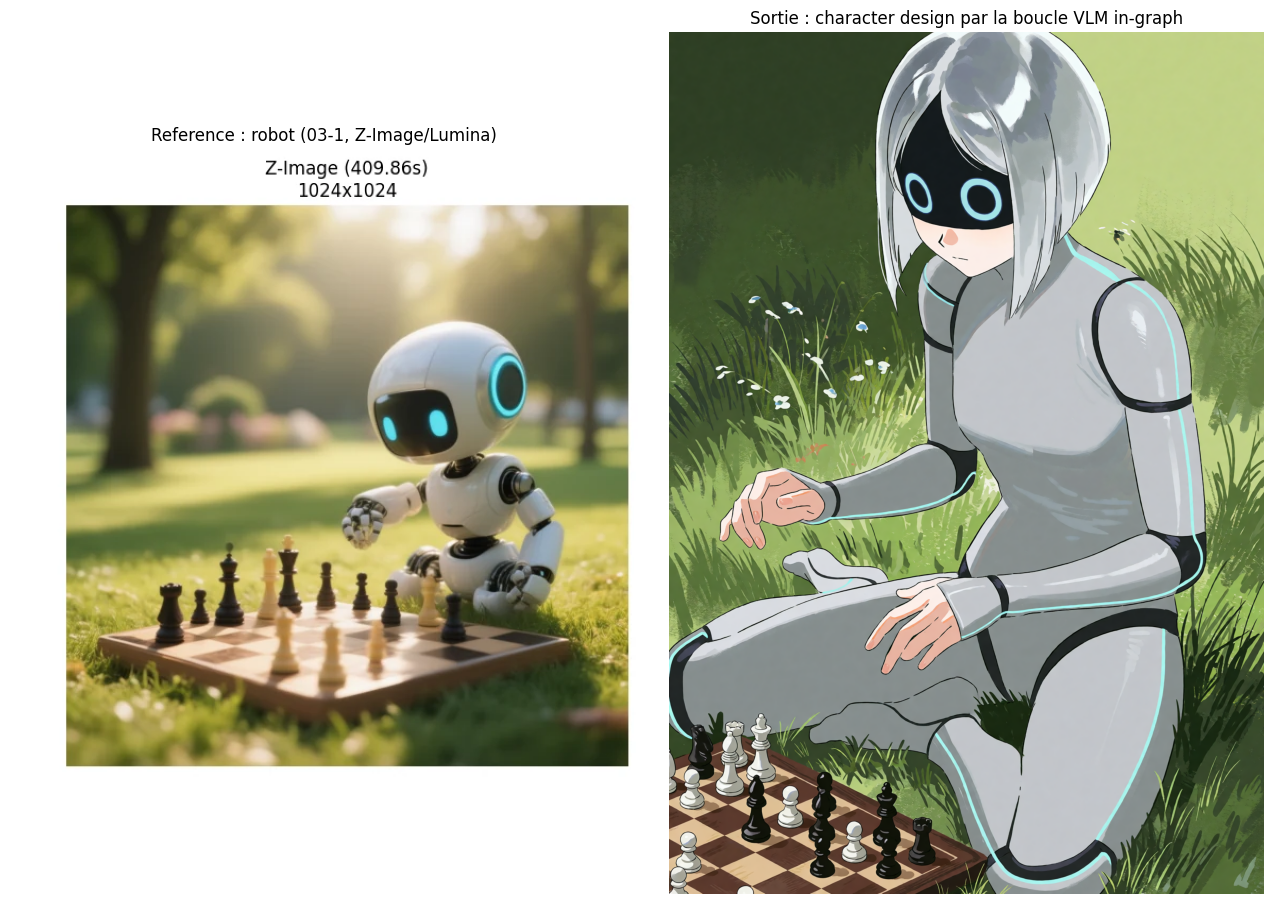


Extrait du prompt final encode (trigger words + VLM) :
"banjiesock2style, illustration **Final Answer**

A young woman with a sleek, minimalist silhouette, her head shaped like a smooth, rounded dome with two glowing cyan circular eyes set within a dark, recessed fac..."


In [8]:
# =============================================================================
# 6. SOUS-GRAPHE DIFFUSION COMPLET (Krea 2 turbo + LoRA banjiesock)
# =============================================================================

WIDTH, HEIGHT = 1280, 1856        # ResolutionMaster de l'original, mode manuel
TRIGGER_WORDS = 'banjiesock2style, illustration'   # TriggerWord Toggle de l'original
SEED = 20260917                   # notre execution, reproductible elle aussi

def run_diffusion_stage(vlm_prompt, seed, use_lora=True,
                        width=WIDTH, height=HEIGHT, prefix=''):
    """Couloir diffusion : latent vide -> LoRA (optionnel) -> encode -> sample -> save."""
    graph = {
        'unet': {'class_type': 'UNETLoader',
                 'inputs': {'unet_name': 'krea2_turbo_int8_convrot.safetensors',
                            'weight_dtype': 'default'}},
        'clip': {'class_type': 'CLIPLoader',
                 'inputs': {'clip_name': 'qwen3vl_4b_bf16.safetensors',
                            'type': 'krea2', 'device': 'default'}},
        'vae': {'class_type': 'VAELoader',
                'inputs': {'vae_name': 'qwen_image_vae.safetensors'}},
        'latent': {'class_type': 'EmptySD3LatentImage',
                   'inputs': {'width': width, 'height': height, 'batch_size': 1}},
        'full_prompt': TRIGGER_WORDS + ' ' + vlm_prompt if use_lora else vlm_prompt,
        'ks': {'class_type': 'KSampler', 'inputs': {
            'seed': seed, 'steps': 8, 'cfg': 1.0, 'sampler_name': 'er_sde',
            'scheduler': 'simple', 'denoise': 1.0,
            'model': ['unet', 0],
            'positive': ['enc', 0], 'negative': ['zero', 0],
            'latent_image': ['latent', 0]}},
        'zero': {'class_type': 'ConditioningZeroOut', 'inputs': {'conditioning': ['enc', 0]}},
        'dec': {'class_type': 'VAEDecode', 'inputs': {'samples': ['ks', 0], 'vae': ['vae', 0]}},
        'save': {'class_type': 'SaveImage',
                 'inputs': {'filename_prefix': f'krea2_character/{prefix}robot_seed{seed}',
                            'images': ['dec', 0]}},
    }
    if use_lora:
        graph['lora'] = {'class_type': 'LoraLoader', 'inputs': {
            'lora_name': 'banjiesock_Krea2.safetensors', 'strength_model': 1.0,
            'strength_clip': 1.0, 'model': ['unet', 0], 'clip': ['clip', 0]}}
        graph['enc'] = {'class_type': 'CLIPTextEncode',
                        'inputs': {'text': graph['full_prompt'], 'clip': ['lora', 1]}}
        graph['ks']['inputs']['model'] = ['lora', 0]
    else:
        graph['enc'] = {'class_type': 'CLIPTextEncode',
                        'inputs': {'text': graph['full_prompt'], 'clip': ['clip', 0]}}
    graph.pop('full_prompt')

    outputs, elapsed = queue_and_wait(graph)
    images = outputs['save']['images']
    r = session.get(f"{COMFYUI_URL}/view", timeout=120,
                    params={'filename': images[0]['filename'],
                            'subfolder': images[0]['subfolder'],
                            'type': images[0]['type']})
    r.raise_for_status()
    return Image.open(io.BytesIO(r.content)), elapsed

img_lora, t_diff = run_diffusion_stage(vlm_prompt, SEED, use_lora=True, prefix='with_')
print(f'Diffusion terminee en {t_diff:.0f}s (chargement du UNet int8 inclus au premier passage)')

fig, ax = plt.subplots(1, 2, figsize=(13, 9))
ax[0].imshow(Image.open(ASSETS / 'reference_robot.png'))
ax[0].set_title('Reference : robot (03-1, Z-Image/Lumina)')
ax[1].imshow(img_lora)
ax[1].set_title('Sortie : character design par la boucle VLM in-graph')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

print('\nExtrait du prompt final encode (trigger words + VLM) :')
print(f'"{TRIGGER_WORDS} {vlm_prompt[:180]}..."')

## 7. La démonstration clé : le style vit dans le LoRA, pas dans le prompt

Le system prompt interdit au VLM de prescrire un style -- par conception. Si notre lecture
est correcte, **le même prompt VLM sans le LoRA** doit produire le même personnage dans un
rendu générique, sans l'esthétique *blueprint sheet*. Lançons la diffusion sans LoRA (et
sans ses trigger words, qui ne signifient rien hors du LoRA) : le contraste des deux
images isole expérimentalement ce que le LoRA apporte.

Diffusion sans LoRA terminee en 145s


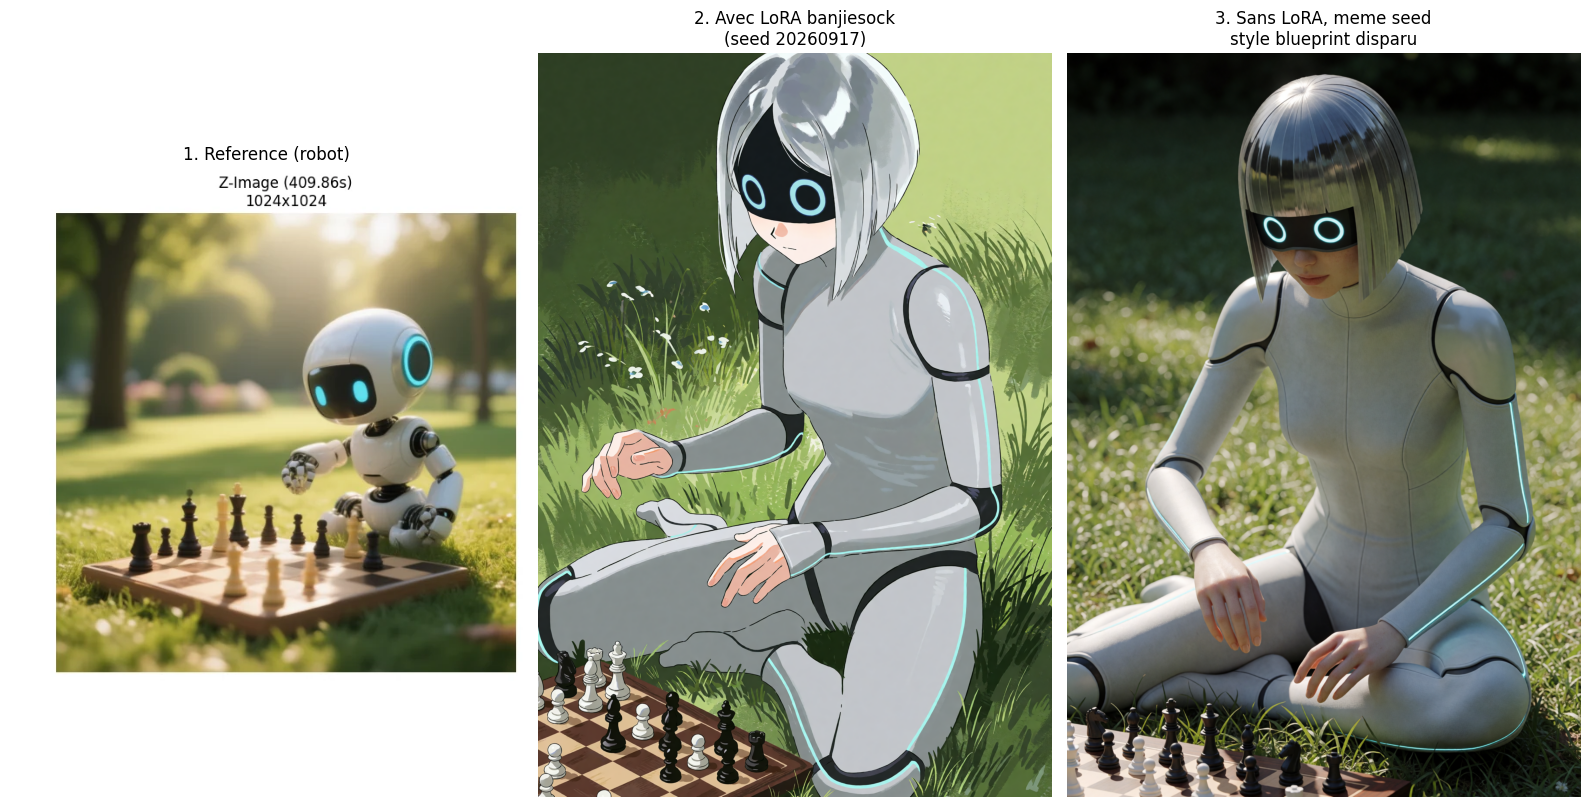

In [9]:
# =============================================================================
# 7. DIFFUSION SANS LORA : ISOLER LA CONTRIBUTION DU STYLE
# =============================================================================
img_plain, t_plain = run_diffusion_stage(vlm_prompt, SEED, use_lora=False, prefix='nolora_')
print(f'Diffusion sans LoRA terminee en {t_plain:.0f}s')

fig, ax = plt.subplots(1, 3, figsize=(16, 8))
ax[0].imshow(Image.open(ASSETS / 'reference_robot.png'))
ax[0].set_title('1. Reference (robot)')
ax[1].imshow(img_lora)
ax[1].set_title(f'2. Avec LoRA banjiesock\n(seed {SEED})')
ax[2].imshow(img_plain)
ax[2].set_title(f'3. Sans LoRA, meme seed\nstyle blueprint disparu')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

L'image source qui a motivé ce notebook (celle de l'auteur du workflow, avec **sa**
référence d'entrée à lui) :

<p align="center">
  <img src="assets/krea2-character/source_character_sheet.png" width="380" alt="Character sheet blueprint produite par l'auteur du workflow avec sa propre image de reference.">
</p>

Même pipeline, autre référence d'entrée, même LoRA : le couloir VLM a fait le travail
d'adaptation. C'est la propriété qui rend ce workflow réutilisable : **changer la
référence change le personnage ; changer le LoRA change le style ; ni l'un ni l'autre ne
demande de réécrire le prompt système.**

---
## Exercice 1 : votre référence, votre personnage

**Durée estimée :** 15-20 minutes

Le contrat du pipeline est de fonctionner sur *n'importe quelle* référence visuelle --
mais la note de la section 5 a montré que le VLM 4B refuse les paysages. Prenez le
paysage urbain cyberpunk du notebook `01-1` (`../assets/readme/dalle3-cover.webp`),
constatez le refus, puis faites tourner la boucle sur une référence acceptée de votre
choix (animal, plante, objet, créature).

**Cahier des charges :**
1. Uploader le paysage cyberpunk et lancer `run_vlm_stage` : relever le message de
   refus, l'argument qu'il avance, et le confronter au contrat écrit du system prompt.
2. Choisir une référence non-paysage (une image d'objet/animal que vous générez avec
   les notebooks précédents, ou toute image locale), lancer la boucle complète.
3. Comparer le prompt généré à celui du robot : quelles caractéristiques visuelles ont
   été traduites (couleurs, formes, matière) ? Le genre choisi diffère-t-il ?
4. Générer l'image finale avec `run_diffusion_stage` et commenter la fidélité de la
   traduction « visual DNA → personnage ».

In [10]:
# Exercice 1 : a completer
# TODO etudiant : uploader la reference cyberpunk et lancer la boucle complete
# Etape 1 - nouvelle reference
# ref_cyberpunk = upload_reference(Path('../assets/readme/dalle3-cover.webp'), 'ref_cyberpunk.png')
# Etape 2 - constater le refus du paysage, puis reussir avec une reference objet
# vlm_prompt_cyber = run_vlm_stage(ref_cyberpunk, system_prompt, seed=0)  # -> refus attendu
# print(vlm_prompt_cyber)
# Etape 3 - generation finale
# img_cyber, _ = run_diffusion_stage(vlm_prompt_cyber, SEED, use_lora=True, prefix='cyber_')
# img_cyber
print('Exercice 1 a completer : decommenter et adapter les etapes ci-dessus')

Exercice 1 a completer : decommenter et adapter les etapes ci-dessus


## Exercice 2 : température et stabilité du design

**Durée estimée :** 15 minutes

Le `TextGenerate` de l'original échantillonne à `temperature=0.7`. La question de design :
le personnage produit à partir d'une même référence est-il **stable** sous la variabilité
d'échantillonnage, ou chaque tirage invente-t-il un personnage différent ? C'est la
différence entre un *générateur de prompts* et un *extracteur d'identité visuelle*.

**Cahier des charges :**
1. Relancer `run_vlm_stage` sur la référence robot à `temperature=0.3` puis `1.2`
   (mêmes seeds).
2. Pour chaque prompt généré, relever : le genre retenu, les trois couleurs dominantes,
   le motif signature.
3. Conclure : à partir de quel écart de température l'identité du personnage dérive-t-elle ?
   Quelles parties du prompt restent invariantes (probablement celles ancrées dans
   l'image) et lesquelles varient (celles que le VLM *invente*) ?

In [11]:
# Exercice 2 : a completer
# TODO etudiant : mesurer la stabilite du design sous temperature variable
# Etape 1 - deux tirages
# p_low, _ = run_vlm_stage(ref_name, system_prompt, seed=0, temperature=0.3)
# p_high, _ = run_vlm_stage(ref_name, system_prompt, seed=0, temperature=1.2)
# Etape 2 - relever genre / couleurs / motif dans chaque prompt (reference robot)
# Etape 3 - conclure sur la frontiere extraction vs invention
print('Exercice 2 a completer : comparer temperature=0.3 et temperature=1.2')

Exercice 2 a completer : comparer temperature=0.3 et temperature=1.2


## Exercice 3 : changer de canal de style

**Durée estimée :** 15-20 minutes

L'auteur du workflow utilise le LoRA `banjiesock_Krea2` (Civitai). Krea publie ses
propres LoRA de style sur `Comfy-Org/Krea-2` (dossier `loras/`), chacun avec son trigger
word officiel : `krea2_retroanime` → `purple retro anime style`, `krea2_softwatercolor`
→ `art deco watercolor style`, etc. L'architecture « design dans le prompt, style dans le
LoRA » promet que **le personnage survit au changement de LoRA**.

**Cahier des charges :**
1. Télécharger un LoRA officiel (par exemple `krea2_retroanime.safetensors`,
   ~0,5 Go : `https://huggingface.co/Comfy-Org/Krea-2/resolve/main/loras/krea2_retroanime.safetensors`)
   dans `docker-configurations/shared/models/loras/`.
2. Généraliser `run_diffusion_stage` en paramètres `lora_name` et `trigger_words`
   (c'est le seul endroit du pipeline qui connaisse le style).
3. Générer le même personnage (même prompt VLM, même seed) en style retro anime et en
   style banjiesock, et comparer : l'identité (visage, palette, silhouette) persiste-t-elle
   à travers les deux rendus ?

In [12]:
# Exercice 3 : a completer
# TODO etudiant : parametrer le canal de style
# Etape 1 - telecharger krea2_retroanime.safetensors (cf. enonce) dans models/loras/
# Etape 2 - generaliser la signature :
# def run_diffusion_stage_styled(vlm_prompt, seed, lora_name, trigger_words, ...):
#     ...  # meme corps que run_diffusion_stage, seuls lora_name/trigger_words changent
# Etape 3 - comparer les deux rendus du meme personnage
print('Exercice 3 a completer : LoRA retroanime + trigger word officiel')

Exercice 3 a completer : LoRA retroanime + trigger word officiel


## Récapitulatif

| Concept | Dans le workflow | Leçon |
|---|---|---|
| PNG auto-documenté | chunks `tEXt` `prompt` (API) + `workflow` (UI) | une image générée embarque sa recette : forensics par parsing binaire, reproductibilité par défaut |
| Deux formats d'un graphe | `prompt` = programme, `workflow` = capture UI | seul le format API est exécutable ; le second sert à l'éditeur |
| Boucle VLM in-graph | `TextGenerate` + `CLIPLoader` (LLM multimodal) | ComfyUI n'est pas qu'un générateur : le graphe peut *raisonner* avant de générer |
| Prompt système « visual DNA » | 11 235 caractères de contraintes | la qualité du pipeline est dans le texte : humain obligatoire, genre choisi, neutralité de style, traduction métaphorique |
| Séparation design / style | prompt VLM (identité) + LoRA (rendu) | deux canaux composables : changer la référence change le personnage, changer le LoRA change le style |
| Distillation turbo | 8 steps, CFG 1.0, `ConditioningZeroOut` | peu de pas, pas de guidance : le négatif est mis à zéro plutôt que factice |
| Custom vs natif | 6 custom nodes remplacés | un bon workflow se lit et se **transpose** : l'architecture survit aux nodes manquants |

### Pour aller plus loin

- **Workflow UI complet** : le fichier `assets/krea2-character/workflow_ui.json` se
  dépose directement dans l'interface ComfyUI (menu → Load) pour explorer le graphe
  original en interactif.
- **SageAttention** : le node `PathchSageAttentionKJ` de l'original (désactivé dans
  l'exécution capturée) active le noyau d'attention quantifiée pour accélérer le
  sampling -- sujet du notebook `03-3` (Performance Optimization).
- **Agentic in-graph** : la boucle VLM est un cas simple de *tool use inside the graph* ;
  les notebooks du niveau Applications poussent le principe plus loin (chaînes
  multi-étapes, auto-critique, sélection de modèle).

In [13]:
# =============================================================================
# FIN DU NOTEBOOK - verification d'integrite
# =============================================================================
print('Pipeline rejoue : forensics PNG -> lecture du graphe -> boucle VLM -> diffusion Krea 2')
print(f'Reference : robot (03-1) | VLM : qwen3vl_4b | UNet : krea2_turbo_int8_convrot')
print(f'LoRA : banjiesock_Krea2 | seed : {SEED} | resolution : {WIDTH}x{HEIGHT}')
print('Notebook executable de bout en bout - exercices 1 a 3 laisses en stub.')

Pipeline rejoue : forensics PNG -> lecture du graphe -> boucle VLM -> diffusion Krea 2
Reference : robot (03-1) | VLM : qwen3vl_4b | UNet : krea2_turbo_int8_convrot
LoRA : banjiesock_Krea2 | seed : 20260917 | resolution : 1280x1856
Notebook executable de bout en bout - exercices 1 a 3 laisses en stub.
